In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Business Objective

**NLP Sentiment Analysis:** Extracting sentiment from customer reviews on a product.

The project objective requires customer reviews from an e-commerce source such as Amazon and deployment of the final sentiment-analysis result using Streamlit, R Shiny, Flask, or a similar framework.

In [2]:
df = pd.read_excel('/content/dataset.xlsx')

In [3]:
df.head()

,title,rating,body
0,Horrible product,1,Very disappointed with the overall performance...
1,Camera quality is not like 48 megapixel,3,Camera quality is low
2,Overall,4,"Got the mobile on the launch date,Battery must..."
3,A big no from me,1,1. It doesn't work with 5.0GHz WiFi frequency....
4,Put your money somewhere else,1,"Not worth buying....faulty software, poor disp..."


In [4]:
df.shape

(1440, 3)

In [5]:
df.columns

Index(['title', 'rating', 'body'], dtype='object')

In [6]:
df.columns = df.columns.str.strip()

In [7]:
df.columns

Index(['title', 'rating', 'body'], dtype='object')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1440 entries, 0 to 1439
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   title   1440 non-null   object
 1   rating  1440 non-null   int64 
 2   body    1440 non-null   object
dtypes: int64(1), object(2)
memory usage: 33.9+ KB


In [9]:
df.describe(include='all')

,title,rating,body
count,1440,1440.000000,1440
unique,1351,NaN,1440
top,Value for money,NaN,Good phone for budget buyers. Sound quality is...
freq,16,NaN,1
mean,NaN,3.173611,NaN
std,NaN,1.584453,NaN
min,NaN,1.000000,NaN
25%,NaN,1.000000,NaN
50%,NaN,4.000000,NaN
75%,NaN,5.000000,NaN


In [10]:
df['rating'].value_counts().sort_index()

,count
rating,
1,386
2,126
3,199
4,310
5,419


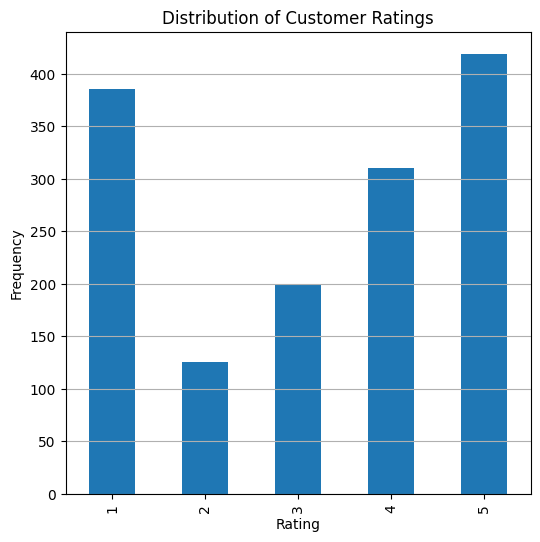

In [11]:
plt.figure(figsize=(6,6))
df['rating'].value_counts().sort_index().plot(kind='bar')
plt.title('Distribution of Customer Ratings')
plt.xlabel('Rating')
plt.ylabel('Frequency')
plt.grid(axis='y')
plt.show()

In [12]:
df['rating'].value_counts(normalize=True).sort_index() * 100

,proportion
rating,
1,26.805556
2,8.750000
3,13.819444
4,21.527778
5,29.097222


In [13]:
df.isnull().sum()

,0
title,0
rating,0
body,0


In [14]:
df.duplicated().sum()

np.int64(0)

### Review Text Preparation

The dataset contains the review title, rating, and review body.

For sentiment modelling:

- `title` and `body` are combined into one review text.
- `rating` is used only to create the sentiment target.
- `rating` is **not** given to the machine-learning model, because that would cause target leakage.

In [15]:
df['title'] = df['title'].fillna('').astype(str)
df['body'] = df['body'].fillna('').astype(str)

df['text'] = (
    df['title'] + ' ' + df['body']
).str.replace(r'\s+', ' ', regex=True).str.strip()

df[['title', 'rating', 'body', 'text']].head()

,title,rating,body,text
0,Horrible product,1,Very disappointed with the overall performance...,Horrible product Very disappointed with the ov...
1,Camera quality is not like 48 megapixel,3,Camera quality is low,Camera quality is not like 48 megapixel Camera...
2,Overall,4,"Got the mobile on the launch date,Battery must...","Overall Got the mobile on the launch date,Batt..."
3,A big no from me,1,1. It doesn't work with 5.0GHz WiFi frequency....,A big no from me 1. It doesn't work with 5.0GH...
4,Put your money somewhere else,1,"Not worth buying....faulty software, poor disp...",Put your money somewhere else Not worth buying...


### Sentiment Label Definition

Because the supplied dataset contains star ratings rather than a separate sentiment column, the target is derived as follows:

| Rating | Sentiment |
|---|---|
| 1–2 | Negative |
| 3 | Neutral |
| 4–5 | Positive |

This rule is kept fixed throughout the project.

In [16]:
df['sentiment'] = np.select(
    [
        df['rating'].isin([1, 2]),
        df['rating'].eq(3),
        df['rating'].isin([4, 5])
    ],
    [
        'negative',
        'neutral',
        'positive'
    ],
    default='unknown'
)

df['sentiment'].value_counts()

,count
sentiment,
positive,729
negative,512
neutral,199


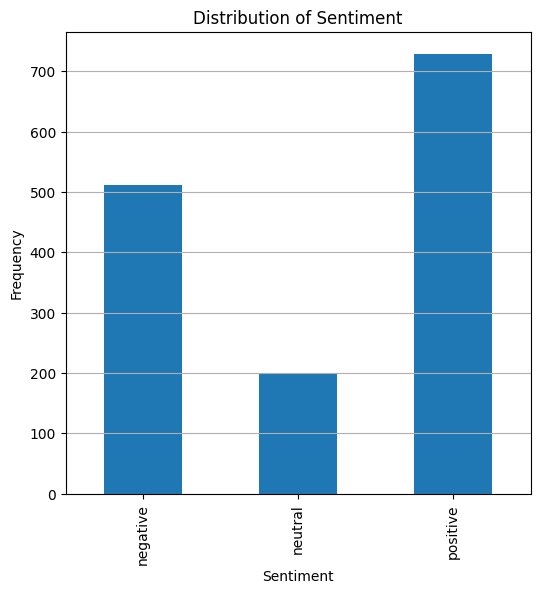

In [17]:
plt.figure(figsize=(6,6))
df['sentiment'].value_counts().reindex(['negative', 'neutral', 'positive']).plot(kind='bar')
plt.title('Distribution of Sentiment')
plt.xlabel('Sentiment')
plt.ylabel('Frequency')
plt.grid(axis='y')
plt.show()

In [18]:
df['text_length'] = df['text'].str.len()
df['word_count'] = df['text'].str.split().str.len()

df[['text_length', 'word_count']].describe()

,text_length,word_count
count,1440.000000,1440.000000
mean,332.231944,58.257639
std,228.672154,39.896874
min,9.000000,2.000000
25%,197.000000,34.000000
50%,276.000000,49.000000
75%,394.000000,70.000000
max,2510.000000,391.000000


<Figure size 800x500 with 0 Axes>

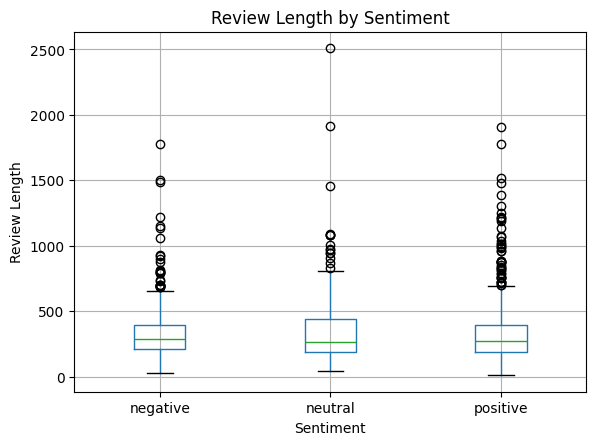

In [19]:
plt.figure(figsize=(8,5))
df.boxplot(column='text_length', by='sentiment')
plt.title('Review Length by Sentiment')
plt.suptitle('')
plt.xlabel('Sentiment')
plt.ylabel('Review Length')
plt.show()

### Duplicate Review Check

Repeated review text can cause data leakage if the same review appears in both training and testing data.

Therefore, the original dataset is kept unchanged for reference, while exact duplicate review texts are removed **only for model building**.

In [20]:
model_df = df[
    (df['text'].str.len() > 0) &
    (df['sentiment'] != 'unknown')
].drop_duplicates(subset=['text']).copy()

model_df.shape

(1440, 7)

In [21]:
model_df['sentiment'].value_counts()

,count
sentiment,
positive,729
negative,512
neutral,199


### EDA Findings

- The dataset contains customer reviews with title, rating, and review body.
- The target sentiment is derived from the supplied star rating.
- The sentiment classes are negative, neutral, and positive.
- Positive reviews form the largest class, while neutral reviews are the smallest.
- Duplicate review texts were checked and removed from the modelling dataset to reduce the possibility of train/test leakage.
- Rating is used to create the target only and is not used as a model feature.

## Model Building

In [22]:
from sklearn.model_selection import train_test_split

X = model_df['text']
y = model_df['sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (1152,)
Testing data: (288,)


### Text Feature Extraction

Machine-learning algorithms cannot directly use raw text.

TF-IDF converts the review text into numerical features.

We use:

- Unigrams: individual words
- Bigrams: two-word phrases
- Sublinear TF scaling

In [23]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline

### Logistic Regression

In [24]:
from sklearn.linear_model import LogisticRegression

logistic_model = Pipeline([
    ('tfidf', TfidfVectorizer(
        lowercase=True,
        ngram_range=(1, 2),
        min_df=1,
        sublinear_tf=True,
        max_features=50000
    )),
    ('model', LogisticRegression(
        max_iter=2000,
        class_weight='balanced'
    ))
])

logistic_model.fit(X_train, y_train)

y_pred_logistic = logistic_model.predict(X_test)

In [25]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score

print("Accuracy:", accuracy_score(y_test, y_pred_logistic))

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_logistic,
    target_names=['Negative', 'Neutral', 'Positive']
))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_logistic))

Accuracy: 0.7743055555555556

Classification Report:
              precision    recall  f1-score   support

    Negative       0.79      0.85      0.82       102
     Neutral       0.32      0.17      0.23        40
    Positive       0.83      0.88      0.85       146

    accuracy                           0.77       288
   macro avg       0.65      0.64      0.63       288
weighted avg       0.74      0.77      0.76       288


Confusion Matrix:
[[ 87   6   9]
 [ 15   7  18]
 [  8   9 129]]


### Multinomial Naive Bayes

In [26]:
from sklearn.naive_bayes import MultinomialNB

naive_bayes = Pipeline([
    ('tfidf', TfidfVectorizer(
        lowercase=True,
        ngram_range=(1, 2),
        min_df=1,
        sublinear_tf=True,
        max_features=50000
    )),
    ('model', MultinomialNB())
])

naive_bayes.fit(X_train, y_train)

y_pred_nb = naive_bayes.predict(X_test)

In [27]:
print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred_nb))

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_nb,
    target_names=['Negative', 'Neutral', 'Positive']
))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_nb))

Naive Bayes Accuracy: 0.6736111111111112

Classification Report:
              precision    recall  f1-score   support

    Negative       0.91      0.48      0.63       102
     Neutral       0.00      0.00      0.00        40
    Positive       0.62      0.99      0.76       146

    accuracy                           0.67       288
   macro avg       0.51      0.49      0.46       288
weighted avg       0.64      0.67      0.61       288


Confusion Matrix:
[[ 49   0  53]
 [  4   0  36]
 [  1   0 145]]


/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### Linear Support Vector Machine

In [28]:
from sklearn.svm import LinearSVC

svm_linear = Pipeline([
    ('tfidf', TfidfVectorizer(
        lowercase=True,
        ngram_range=(1, 2),
        min_df=1,
        sublinear_tf=True,
        max_features=50000
    )),
    ('model', LinearSVC(
        C=1.0,
        class_weight='balanced'
    ))
])

svm_linear.fit(X_train, y_train)

y_pred_svm = svm_linear.predict(X_test)

In [29]:
print("Linear SVM Accuracy:", accuracy_score(y_test, y_pred_svm))

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_svm,
    target_names=['Negative', 'Neutral', 'Positive']
))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_svm))

Linear SVM Accuracy: 0.7916666666666666

Classification Report:
              precision    recall  f1-score   support

    Negative       0.78      0.84      0.81       102
     Neutral       0.43      0.15      0.22        40
    Positive       0.83      0.93      0.88       146

    accuracy                           0.79       288
   macro avg       0.68      0.64      0.64       288
weighted avg       0.76      0.79      0.76       288


Confusion Matrix:
[[ 86   5  11]
 [ 17   6  17]
 [  7   3 136]]


### Model Comparison

The models are compared using:

- Accuracy
- Macro F1
- Weighted F1

**Macro F1** is important here because the neutral class is smaller than the other two classes. It gives each sentiment class equal importance.

In [30]:
results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Multinomial Naive Bayes',
        'Linear SVM'
    ],

    'Accuracy': [
        accuracy_score(y_test, y_pred_logistic),
        accuracy_score(y_test, y_pred_nb),
        accuracy_score(y_test, y_pred_svm)
    ],

    'Macro F1': [
        f1_score(y_test, y_pred_logistic, average='macro'),
        f1_score(y_test, y_pred_nb, average='macro'),
        f1_score(y_test, y_pred_svm, average='macro')
    ],

    'Weighted F1': [
        f1_score(y_test, y_pred_logistic, average='weighted'),
        f1_score(y_test, y_pred_nb, average='weighted'),
        f1_score(y_test, y_pred_svm, average='weighted')
    ]
})

results.sort_values(
    by='Macro F1',
    ascending=False
)

,Model,Accuracy,Macro F1,Weighted F1
2,Linear SVM,0.791667,0.636987,0.763010
0,Logistic Regression,0.774306,0.633622,0.755131
1,Multinomial Naive Bayes,0.673611,0.463788,0.609368


### Hyperparameter Tuning for Linear SVM

In [31]:
from sklearn.model_selection import GridSearchCV

svm = Pipeline([
    ('tfidf', TfidfVectorizer(
        lowercase=True,
        ngram_range=(1, 2),
        min_df=1,
        sublinear_tf=True,
        max_features=50000
    )),
    ('model', LinearSVC())
])

param_grid = {
    'model__C': [0.1, 0.5, 1, 2, 5],
    'model__class_weight': [None, 'balanced']
}

grid_search = GridSearchCV(
    svm,
    param_grid,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

best_svm = grid_search.best_estimator_

In [32]:
print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Cross Validation Macro F1:")
print(grid_search.best_score_)

Best Parameters:
{'model__C': 2, 'model__class_weight': 'balanced'}

Best Cross Validation Macro F1:
0.6393642401284796


In [33]:
y_pred_best = best_svm.predict(X_test)

print("Tuned SVM Accuracy:", accuracy_score(y_test, y_pred_best))
print("Tuned SVM Macro F1:", f1_score(y_test, y_pred_best, average='macro'))

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_best,
    target_names=['Negative', 'Neutral', 'Positive']
))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_best))

Tuned SVM Accuracy: 0.7916666666666666
Tuned SVM Macro F1: 0.6369874439259711

Classification Report:
              precision    recall  f1-score   support

    Negative       0.78      0.84      0.81       102
     Neutral       0.43      0.15      0.22        40
    Positive       0.83      0.93      0.88       146

    accuracy                           0.79       288
   macro avg       0.68      0.64      0.64       288
weighted avg       0.76      0.79      0.76       288


Confusion Matrix:
[[ 86   5  11]
 [ 17   6  17]
 [  7   3 136]]


### Final Model Selection

The final model selected for the project is a **TF-IDF + Linear Support Vector Machine (SVM)**.

The model was selected based on **Macro F1** after comparing Logistic Regression, Multinomial Naive Bayes, and Linear SVM, followed by 5-fold hyperparameter tuning.

The selected configuration from the completed experiment is:

- TF-IDF word unigrams and bigrams
- `C = 2`
- `class_weight = 'balanced'`
- 5-fold GridSearchCV
- Final training on the complete cleaned modelling dataset

The hold-out test accuracy is approximately **79.17%**, with a Macro F1 of approximately **63.70%**.

The neutral class remains the most difficult class to identify, which is an important limitation to mention during the project review.

In [34]:
final_model = best_svm

In [35]:
final_model.fit(X, y)

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_features=50000, ngram_range=(1, 2),
                                 sublinear_tf=True)),
                ('model', LinearSVC(C=2, class_weight='balanced'))])

### Sample Prediction

In [36]:
sample_review = [
    "The product is excellent. The quality is very good and I am completely satisfied."
]

prediction = final_model.predict(sample_review)

prediction

array(['positive'], dtype=object)

In [37]:
print("Prediction:", prediction[0].title())

Prediction: Positive


In [38]:
sample_review = [
    "The product is terrible. The quality is very poor and I regret buying it."
]

prediction = final_model.predict(sample_review)

print("Prediction:", prediction[0].title())

Prediction: Negative


### Save the Final Model

The complete TF-IDF + SVM pipeline is saved as one model file.

This is important because the Streamlit application must use the **same TF-IDF preprocessing and trained classifier** used during training.

In [39]:
import joblib

joblib.dump(final_model, 'sentiment_model.pkl')

['sentiment_model.pkl']

In [40]:
import os

print(os.listdir())

['.config', 'sentiment_model.pkl', 'dataset.xlsx', 'sample_data']


### Final Project Flow

Customer Review

↓

Title + Review Body

↓

Text Cleaning

↓

TF-IDF

↓

Linear SVM

↓

Sentiment Prediction

↓

Negative / Neutral / Positive

The saved `sentiment_model.pkl` can be loaded directly by the Streamlit application.

## 🔗 Project Links

- **Live Demo (Streamlit App):** https://sentiment-analysis-ha3fhjjpptpvtfendzhete.streamlit.app/
- **GitHub Repository:** https://github.com/praveenguvvala01-wq/sentiment-analysis

Explore the interactive web application to test customer review sentiment predictions, or visit the GitHub repository to view the source code, notebook, model implementation, and project documentation.